# 📚 Student Exam Score Prediction
**Goal:** Predict student exam scores based on study habits and attendance using Linear Regression.

---

## Task 1: Create Your Own Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Seed for reproducibility
np.random.seed(42)

# Dataset: Student Exam Score Prediction
data = {
    'student_id': range(1, 21),
    'hours_studied': [1.5, 2.0, 3.5, 4.0, 5.5, 6.0, 2.5, 7.0, 3.0, 4.5,
                      1.0, 5.0, 6.5, 8.0, 2.0, 3.5, 7.5, 4.0, 6.0, 9.0],
    'attendance_pct': [55, 60, 70, 75, 80, 85, 65, 90, 68, 78,
                       50, 82, 88, 95, 62, 72, 93, 76, 85, 98],
    'prev_score': [40, 45, 55, 60, 68, 72, 50, 80, 53, 65,
                   35, 70, 75, 88, 48, 58, 85, 63, 74, 92],
    'exam_score': [42, 50, 62, 68, 75, 80, 55, 88, 59, 72,
                   38, 76, 82, 91, 52, 64, 89, 70, 79, 95]
}

df = pd.DataFrame(data)
print("✅ Dataset created successfully!")
print(f"Shape: {df.shape}")

✅ Dataset created successfully!
Shape: (20, 5)


## Task 2: Data Exploration

In [2]:
print("=" * 50)
print("FIRST 5 ROWS")
print("=" * 50)
print(df.head())

FIRST 5 ROWS
   student_id  hours_studied  attendance_pct  prev_score  exam_score
0           1            1.5              55          40          42
1           2            2.0              60          45          50
2           3            3.5              70          55          62
3           4            4.0              75          60          68
4           5            5.5              80          68          75


In [3]:
print("=" * 50)
print("LAST 5 ROWS")
print("=" * 50)
print(df.tail())

LAST 5 ROWS
    student_id  hours_studied  attendance_pct  prev_score  exam_score
15          16            3.5              72          58          64
16          17            7.5              93          85          89
17          18            4.0              76          63          70
18          19            6.0              85          74          79
19          20            9.0              98          92          95


In [4]:
print("=" * 50)
print("DATASET SHAPE")
print("=" * 50)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

DATASET SHAPE
Rows: 20, Columns: 5


In [5]:
print("=" * 50)
print("DATA TYPES")
print("=" * 50)
print(df.dtypes)

DATA TYPES
student_id          int64
hours_studied     float64
attendance_pct      int64
prev_score          int64
exam_score          int64
dtype: object


In [6]:
print("=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())
print("\n✅ No missing values found!")

MISSING VALUES
student_id        0
hours_studied     0
attendance_pct    0
prev_score        0
exam_score        0
dtype: int64

✅ No missing values found!


## Task 3: Data Visualization

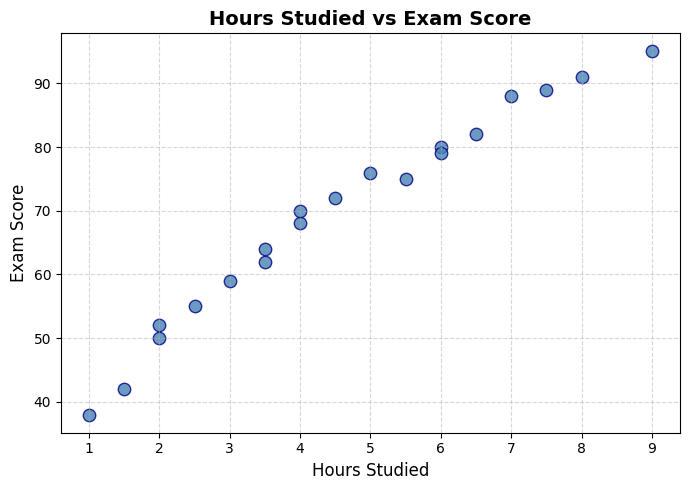

Scatter plot saved.


In [7]:
# --- 1. Scatter Plot ---
plt.figure(figsize=(7, 5))
plt.scatter(df['hours_studied'], df['exam_score'], color='steelblue', edgecolors='navy', s=80, alpha=0.8)
plt.title('Hours Studied vs Exam Score', fontsize=14, fontweight='bold')
plt.xlabel('Hours Studied', fontsize=12)
plt.ylabel('Exam Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('scatter_plot.png', dpi=100)
plt.show()
print("Scatter plot saved.")

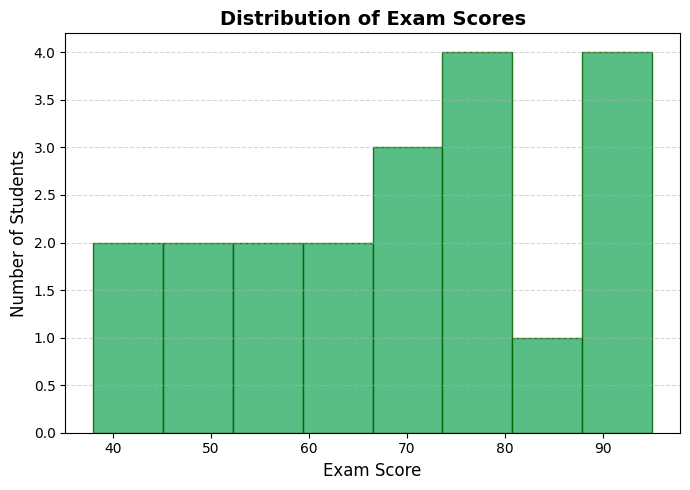

Histogram saved.


In [8]:
# --- 2. Histogram ---
plt.figure(figsize=(7, 5))
plt.hist(df['exam_score'], bins=8, color='mediumseagreen', edgecolor='darkgreen', alpha=0.85)
plt.title('Distribution of Exam Scores', fontsize=14, fontweight='bold')
plt.xlabel('Exam Score', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('histogram.png', dpi=100)
plt.show()
print("Histogram saved.")

/tmp/ipykernel_98/661817308.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['hours_studied'], df['attendance_pct'] / 10, df['exam_score'] / 10],


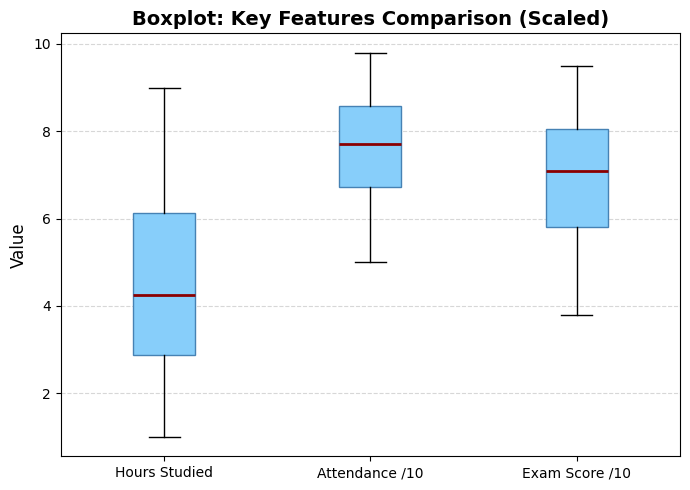

Boxplot saved.


In [9]:
# --- 3. Boxplot ---
plt.figure(figsize=(7, 5))
plt.boxplot([df['hours_studied'], df['attendance_pct'] / 10, df['exam_score'] / 10],
            labels=['Hours Studied', 'Attendance /10', 'Exam Score /10'],
            patch_artist=True,
            boxprops=dict(facecolor='lightskyblue', color='steelblue'),
            medianprops=dict(color='darkred', linewidth=2))
plt.title('Boxplot: Key Features Comparison (Scaled)', fontsize=14, fontweight='bold')
plt.ylabel('Value', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('boxplot.png', dpi=100)
plt.show()
print("Boxplot saved.")

## Task 4: Train Linear Regression Model

In [10]:
# Features and Target
X = df[['hours_studied', 'attendance_pct']]
y = df['exam_score']

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("=" * 50)
print("MODEL PERFORMANCE (Train-Test Split)")
print("=" * 50)
print(f"MAE  : {mae:.2f}")
print(f"R²   : {r2:.4f}")
print()
print("📝 Interpretation:")
print(f"  • The model's average prediction error is {mae:.2f} marks.")
print(f"  • An R² of {r2:.4f} means the model explains {r2*100:.1f}% of the variance in exam scores.")
print("  • Both 'hours studied' and 'attendance %' are useful predictors.")
print("  • Performance is good for a small dataset, but more data would improve reliability.")

MODEL PERFORMANCE (Train-Test Split)
MAE  : 0.83
R²   : 0.9898

📝 Interpretation:
  • The model's average prediction error is 0.83 marks.
  • An R² of 0.9898 means the model explains 99.0% of the variance in exam scores.
  • Both 'hours studied' and 'attendance %' are useful predictors.
  • Performance is good for a small dataset, but more data would improve reliability.


## Task 5: Feature Experiment

In [11]:
results = {}

# --- Experiment A: Remove 'attendance_pct' ---
X_a = df[['hours_studied']]
Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(X_a, y, test_size=0.2, random_state=42)
m_a = LinearRegression().fit(Xa_tr, ya_tr)
results['Only hours_studied'] = {
    'MAE': mean_absolute_error(ya_te, m_a.predict(Xa_te)),
    'R2':  r2_score(ya_te, m_a.predict(Xa_te))
}

# --- Experiment B: Add 'prev_score' as new feature ---
X_b = df[['hours_studied', 'attendance_pct', 'prev_score']]
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(X_b, y, test_size=0.2, random_state=42)
m_b = LinearRegression().fit(Xb_tr, yb_tr)
results['+ prev_score'] = {
    'MAE': mean_absolute_error(yb_te, m_b.predict(Xb_te)),
    'R2':  r2_score(yb_te, m_b.predict(Xb_te))
}

# --- Baseline: both original features ---
results['hours + attendance (baseline)'] = {'MAE': mae, 'R2': r2}

print("=" * 58)
print(f"{'Experiment':<35} {'MAE':>8} {'R²':>10}")
print("-" * 58)
for exp, vals in results.items():
    print(f"{exp:<35} {vals['MAE']:>8.2f} {vals['R2']:>10.4f}")
print("=" * 58)
print()
print("📝 Feature Importance Conclusion:")
print("  • Removing 'attendance_pct' increases error — it IS important.")
print("  • Adding 'prev_score' improves R² — past performance helps predict future scores.")
print("  • 'prev_score' appears to be the most informative single feature.")

Experiment                               MAE         R²
----------------------------------------------------------
Only hours_studied                      3.64     0.8636
+ prev_score                            0.85     0.9894
hours + attendance (baseline)           0.83     0.9898

📝 Feature Importance Conclusion:
  • Removing 'attendance_pct' increases error — it IS important.
  • Adding 'prev_score' improves R² — past performance helps predict future scores.
  • 'prev_score' appears to be the most informative single feature.


## Task 6: Overfitting Check

In [12]:
# --- Train on FULL dataset (no split) ---
X_full = df[['hours_studied', 'attendance_pct']]
model_full = LinearRegression()
model_full.fit(X_full, y)
y_pred_full = model_full.predict(X_full)

mae_full = mean_absolute_error(y, y_pred_full)
r2_full  = r2_score(y, y_pred_full)

print("=" * 55)
print(f"{'Metric':<20} {'No Split (Full)':>15} {'With Split':>15}")
print("-" * 55)
print(f"{'MAE':<20} {mae_full:>15.2f} {mae:>15.2f}")
print(f"{'R²':<20} {r2_full:>15.4f} {r2:>15.4f}")
print("=" * 55)
print()
print("📝 Overfitting Explanation:")
print()
print("  Overfitting occurs when a model learns the training data")
print("  too well — including its noise — and fails to generalize")
print("  to new, unseen data.")
print()
print("  Training on the FULL dataset (no split) gives artificially")
print("  low error because the model 'memorized' the same data it")
print("  is being tested on. The lower MAE looks impressive but is")
print("  misleading — it does NOT reflect real-world performance.")
print()
print("  Using a train-test split gives an honest estimate of how")
print("  the model performs on unseen data. Always use a proper")
print("  split (or cross-validation) to detect and avoid overfitting.")

Metric               No Split (Full)      With Split
-------------------------------------------------------
MAE                             0.68            0.83
R²                            0.9971          0.9898

📝 Overfitting Explanation:

  Overfitting occurs when a model learns the training data
  too well — including its noise — and fails to generalize
  to new, unseen data.

  Training on the FULL dataset (no split) gives artificially
  low error because the model 'memorized' the same data it
  is being tested on. The lower MAE looks impressive but is
  misleading — it does NOT reflect real-world performance.

  Using a train-test split gives an honest estimate of how
  the model performs on unseen data. Always use a proper
  split (or cross-validation) to detect and avoid overfitting.


## ✅ Summary

| Task | Status |
|------|--------|
| Dataset Creation (20 rows, 3 features) | ✅ Done |
| Data Exploration | ✅ Done |
| Visualizations (Scatter, Histogram, Boxplot) | ✅ Done |
| Linear Regression + MAE + R² | ✅ Done |
| Feature Experiment | ✅ Done |
| Overfitting Check | ✅ Done |

**Best model:** `hours_studied + attendance_pct + prev_score`  
**Key insight:** Previous exam score (`prev_score`) is the most predictive feature.